<p align="center">
  <img src="https://images.unsplash.com/photo-1556761175-b413da4baf72?auto=format&fit=crop&w=1600&q=85"
       width="100%" alt="Sentiment Analysis and Machine Learning">
</p>

<h1 align="center">🤖 Web Intelligence and NLP-Based Sentiment Analytics</h1>

<p align="center">
  <b>Notebook 04 — Sentiment Analysis</b><br>
  TF-IDF Text Classification & Model Evaluation
</p>

---

## 📌 Project Overview

This notebook represents the **fourth stage** of the Web Intelligence and NLP-Based Sentiment Analytics project.

The NLP-ready text generated in `03_NLP_Preprocessing.ipynb` is converted into numerical features using **TF-IDF** and used to build baseline machine-learning sentiment classifiers.

### 🎯 Objective

- Prepare sentiment labels
- Convert text into TF-IDF features
- Train multiple classification models
- Predict Positive, Neutral, and Negative sentiment
- Compare model performance
- Evaluate Accuracy, Precision, Recall, and F1-score
- Analyze the Confusion Matrix
- Perform basic error analysis
- Select a baseline best-performing model
- Generate final sentiment predictions
- Save the model, vectorizer, and sentiment dataset

## ⚠️ Important Dataset Limitation

The current **Quotes to Scrape** practice dataset does not contain human-annotated sentiment labels or product ratings.

Therefore, this notebook uses **VADER lexicon-based sentiment scoring to create weak/pseudo labels** for demonstrating the complete ML pipeline.

These labels are useful for learning and pipeline development, but the resulting metrics should **not be interpreted as performance against human ground truth**.

For production-quality evaluation, the same pipeline should later be trained and evaluated on a properly labeled sentiment dataset.

## 🔄 Sentiment Analysis Pipeline

```text
Processed Text
      ↓
Weak Sentiment Labels
      ↓
Train / Test Split
      ↓
TF-IDF Vectorization
      ↓
ML Models
      ↓
Sentiment Prediction
      ↓
Model Evaluation
      ↓
Best Model
      ↓
Final Sentiment Dataset
```

### Candidate Models

```text
Logistic Regression
Multinomial Naive Bayes
Linear SVM
```

## 📓 Notebook Workflow

```text
01. Import Libraries
02. Prepare NLTK Resource
03. Configure Project Paths
04. Load NLP Dataset
05. Validate Required Columns
06. Prepare Text
07. Generate Weak Sentiment Scores
08. Create Sentiment Labels
09. Analyze Label Distribution
10. Train/Test Split
11. TF-IDF Vectorization
12. Train Logistic Regression
13. Train Naive Bayes
14. Train Linear SVM
15. Evaluate Models
16. Compare Models
17. Select Best Model
18. Generate Predictions
19. Generate Prediction Scores
20. Confusion Matrix
21. Error Analysis
22. Prepare Final Dataset
23. Save Dataset
24. Save Model Artifacts
25. Verify Outputs
26. Final Summary
```

## 1. Import Libraries

Import the libraries required for sentiment scoring, TF-IDF feature engineering, machine-learning classification, evaluation, visualization, and model persistence.

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

# NLP
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Persistence
import joblib

# File Management
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Prepare NLTK Resource

Initialize VADER, which will be used only to create **weak sentiment labels** for this practice dataset.

In [2]:
# ============================================================
# VADER SETUP
# ============================================================

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon", quiet=True)

sia = SentimentIntensityAnalyzer()

print("VADER sentiment analyzer initialized.")

VADER sentiment analyzer initialized.


## 3. Configure Project Paths

Load the NLP-ready dataset created by `03_NLP_Preprocessing.ipynb` and define locations for the final dataset and model artifacts.

In [3]:
# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
FINAL_DATA_DIR = DATA_DIR / "final"
MODEL_DIR = PROJECT_ROOT / "models"

NLP_INPUT_FILE = FINAL_DATA_DIR / "nlp_ready_quotes.csv"
SENTIMENT_OUTPUT_FILE = FINAL_DATA_DIR / "sentiment_analysis_results.csv"
BEST_MODEL_FILE = MODEL_DIR / "best_sentiment_model.pkl"
TFIDF_FILE = MODEL_DIR / "tfidf_vectorizer.pkl"

FINAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input Dataset : {NLP_INPUT_FILE}")
print(f"Output Dataset: {SENTIMENT_OUTPUT_FILE}")
print(f"Model Path    : {BEST_MODEL_FILE}")

Input Dataset : D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\final\nlp_ready_quotes.csv
Output Dataset: D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\final\sentiment_analysis_results.csv
Model Path    : D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\models\best_sentiment_model.pkl


## 4. Load NLP-Ready Dataset

Load the processed dataset from the previous notebook.

The `processed_text` column is the primary input for sentiment classification.

In [4]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(NLP_INPUT_FILE)

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (100, 19)


,quote_id,quote_text,author,tags,source_url,text_length,original_text,normalized_text,tokens,filtered_tokens,lemmatized_tokens,stemmed_tokens,processed_text,original_char_count,processed_char_count,original_word_count,processed_word_count,bigrams,trigrams
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,Albert Einstein,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/,115,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,the world as we have created it is a process of our thinking it cannot be changed without changing our thinking,"['the', 'world', 'as', 'we', 'have', 'created', 'it', 'is', 'a', 'process', 'of', 'our', 'thinking', 'it', 'can', 'not', 'be', 'changed', 'without...","['world', 'created', 'process', 'thinking', 'changed', 'without', 'changing', 'thinking']","['world', 'created', 'process', 'thinking', 'changed', 'without', 'changing', 'thinking']","['world', 'creat', 'process', 'think', 'chang', 'without', 'chang', 'think']",world created process thinking changed without changing thinking,115,64,22,8,"['world created', 'created process', 'process thinking', 'thinking changed', 'changed without', 'without changing', 'changing thinking']","['world created process', 'created process thinking', 'process thinking changed', 'thinking changed without', 'changed without changing', 'without..."
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",J.K. Rowling,"abilities, choices",https://quotes.toscrape.com/,85,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",it is our choices harry that show what we truly are far more than our abilities,"['it', 'is', 'our', 'choices', 'harry', 'that', 'show', 'what', 'we', 'truly', 'are', 'far', 'more', 'than', 'our', 'abilities']","['choices', 'harry', 'show', 'truly', 'far', 'abilities']","['choice', 'harry', 'show', 'truly', 'far', 'ability']","['choic', 'harri', 'show', 'truli', 'far', 'abil']",choice harry show truly far ability,85,35,16,6,"['choice harry', 'harry show', 'show truly', 'truly far', 'far ability']","['choice harry show', 'harry show truly', 'show truly far', 'truly far ability']"
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,Albert Einstein,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/,131,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,there are only two ways to live your life one is as though nothing is a miracle the other is as though everything is a miracle,"['there', 'are', 'only', 'two', 'ways', 'to', 'live', 'your', 'life', 'one', 'is', 'as', 'though', 'nothing', 'is', 'a', 'miracle', 'the', 'other'...","['two', 'ways', 'live', 'life', 'one', 'though', 'nothing', 'miracle', 'though', 'everything', 'miracle']","['two', 'way', 'live', 'life', 'one', 'though', 'nothing', 'miracle', 'though', 'everything', 'miracle']","['two', 'way', 'live', 'life', 'one', 'though', 'noth', 'miracl', 'though', 'everyth', 'miracl']",two way live life one though nothing miracle though everything miracle,131,70,26,11,"['two way', 'way live', 'live life', 'life one', 'one though', 'though nothing', 'nothing miracle', 'miracle though', 'though everything', 'everyt...","['two way live', 'way live life', 'live life one', 'life one though', 'one though nothing', 'though nothing miracle', 'nothing miracle though', 'm..."
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",Jane Austen,"aliteracy, books, classic, humor",https://quotes.toscrape.com/,104,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",the person be it gentleman or lady who has not p

## 5. Validate Required Columns

Verify that the expected NLP fields are available before continuing.

In [5]:
# ============================================================
# REQUIRED COLUMN VALIDATION
# ============================================================

required_columns = [
    "quote_id",
    "original_text",
    "processed_text"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("✓ All required columns are available.")

✓ All required columns are available.


## 6. Prepare Text Data

Remove records without usable processed text.

Machine-learning models require non-empty text input.

In [6]:
# ============================================================
# PREPARE TEXT
# ============================================================

df["processed_text"] = (
    df["processed_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

before_rows = len(df)

df = df[df["processed_text"].ne("")].copy()

after_rows = len(df)

print(f"Rows before filtering : {before_rows:,}")
print(f"Rows after filtering  : {after_rows:,}")

Rows before filtering : 100
Rows after filtering  : 100


## 7. Generate Weak Sentiment Scores

Use VADER to calculate sentiment scores for every processed text.

The compound score provides a normalized overall sentiment signal.

In [7]:
# ============================================================
# VADER SENTIMENT SCORING
# ============================================================

def get_vader_scores(text):
    return sia.polarity_scores(text)


vader_scores = df["processed_text"].apply(get_vader_scores)

df["negative_score"] = vader_scores.apply(lambda x: x["neg"])
df["neutral_score"] = vader_scores.apply(lambda x: x["neu"])
df["positive_score"] = vader_scores.apply(lambda x: x["pos"])
df["compound_score"] = vader_scores.apply(lambda x: x["compound"])

display(
    df[
        [
            "processed_text",
            "negative_score",
            "neutral_score",
            "positive_score",
            "compound_score"
        ]
    ].head(10)
)

,processed_text,negative_score,neutral_score,positive_score,compound_score
0,world created process thinking changed without changing thinking,0.000,0.778,0.222,0.2500
1,choice harry show truly far ability,0.000,0.435,0.565,0.6369
2,two way live life one though nothing miracle though everything miracle,0.406,0.594,0.000,-0.7306
3,person gentleman lady pleasure good novel must intolerably stupid,0.197,0.289,0.514,0.6705
4,imperfection beauty madness genius better absolutely ridiculous absolutely boring,0.444,0.208,0.348,-0.2143
5,try become man success rather become man value,0.000,0.496,0.504,0.7269
6,better hated loved,0.382,0.000,0.618,0.3818
7,failed ive found way wont work,0.398,0.602,0.000,-0.5106
8,woman like tea bag never know strong hot water,0.221,0.574,0.205,-0.0521
9,day without sunshine like know night,0.542,0.458,0.000,-0.5773


## 8. Create Weak Sentiment Labels

Convert the VADER compound score into three classes.

```text
compound >=  0.05 → Positive
compound <= -0.05 → Negative
otherwise         → Neutral
```

These labels are explicitly treated as **weak labels** rather than human ground truth.

In [8]:
# ============================================================
# CREATE SENTIMENT LABELS
# ============================================================

def assign_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    return "Neutral"


df["sentiment"] = df["compound_score"].apply(assign_sentiment)

display(
    df[
        ["processed_text", "compound_score", "sentiment"]
    ].head(15)
)

,processed_text,compound_score,sentiment
0,world created process thinking changed without changing thinking,0.2500,Positive
1,choice harry show truly far ability,0.6369,Positive
2,two way live life one though nothing miracle though everything miracle,-0.7306,Negative
3,person gentleman lady pleasure good novel must intolerably stupid,0.6705,Positive
4,imperfection beauty madness genius better absolutely ridiculous absolutely boring,-0.2143,Negative
5,try become man success rather become man value,0.7269,Positive
6,better hated loved,0.3818,Positive
7,failed ive found way wont work,-0.5106,Negative
8,woman like tea bag never know strong hot water,-0.0521,Negative
9,day without sunshine like know night,-0.5773,Negative


## 9. Analyze Sentiment Distribution

Inspect the class distribution before training.

Class imbalance can influence model behavior and evaluation.

In [9]:
# ============================================================
# SENTIMENT DISTRIBUTION
# ============================================================

sentiment_distribution = (
    df["sentiment"]
    .value_counts()
    .rename_axis("sentiment")
    .reset_index(name="count")
)

sentiment_distribution["percentage"] = (
    sentiment_distribution["count"] / len(df) * 100
).round(2)

display(sentiment_distribution)

,sentiment,count,percentage
0,Positive,47,47.0
1,Negative,32,32.0
2,Neutral,21,21.0


## 10. Visualize Sentiment Distribution

Visualize the number of examples in each sentiment class.

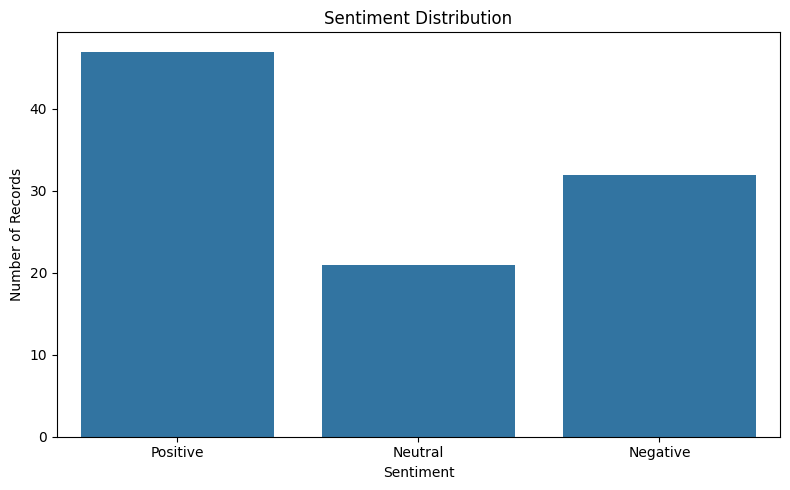

In [10]:
# ============================================================
# SENTIMENT DISTRIBUTION PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sentiment",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## 11. Train/Test Split

Separate the text and sentiment label, then create training and testing subsets.

The test set is kept unseen during model fitting.

In [11]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X = df["processed_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training records: {len(X_train):,}")
print(f"Testing records : {len(X_test):,}")

Training records: 80
Testing records : 20


## 12. TF-IDF Vectorization

Convert text into numerical features using **Term Frequency–Inverse Document Frequency (TF-IDF)**.

The vectorizer is fitted only on training data and then applied to the test data to avoid information leakage.

Unigrams and bigrams are included to capture individual words and short phrases.

In [12]:
# ============================================================
# TF-IDF VECTORIZATION
# ============================================================

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training TF-IDF shape: {X_train_tfidf.shape}")
print(f"Testing TF-IDF shape : {X_test_tfidf.shape}")

Training TF-IDF shape: (80, 1217)
Testing TF-IDF shape : (20, 1217)


## 13. Model 1 — Logistic Regression

Train Logistic Regression as a strong baseline for multi-class text classification.

In [13]:
# ============================================================
# LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

logistic_predictions = logistic_model.predict(X_test_tfidf)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## 14. Model 2 — Multinomial Naive Bayes

Train Multinomial Naive Bayes as an efficient probabilistic baseline for text classification.

In [14]:
# ============================================================
# MULTINOMIAL NAIVE BAYES
# ============================================================

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes trained successfully.")

Multinomial Naive Bayes trained successfully.


## 15. Model 3 — Linear SVM

Train a Linear Support Vector Machine.

Linear SVM is a common and effective classifier for high-dimensional sparse TF-IDF features.

In [15]:
# ============================================================
# LINEAR SVM
# ============================================================

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_predictions = svm_model.predict(X_test_tfidf)

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


## 16. Model Evaluation

Evaluate each classifier using:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score

The weighted F1-score is used as the primary comparison metric.

In [16]:
# ============================================================
# MODEL EVALUATION
# ============================================================

def evaluate_model(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),
        "recall_weighted": recall_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        )
    }


results_df = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions
    ),
    evaluate_model(
        "Multinomial Naive Bayes",
        y_test,
        nb_predictions
    ),
    evaluate_model(
        "Linear SVM",
        y_test,
        svm_predictions
    )
])

display(results_df)

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Logistic Regression,0.55,0.563158,0.55,0.430542
1,Multinomial Naive Bayes,0.55,0.563158,0.55,0.430542
2,Linear SVM,0.50,0.466667,0.50,0.453333


## 17. Detailed Classification Reports

Generate class-level precision, recall, and F1-score for every candidate model.

In [17]:
# ============================================================
# CLASSIFICATION REPORTS
# ============================================================

models_predictions = {
    "Logistic Regression": logistic_predictions,
    "Multinomial Naive Bayes": nb_predictions,
    "Linear SVM": svm_predictions
}

for model_name, predictions in models_predictions.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    Negative       1.00      0.17      0.29         6
     Neutral       0.00      0.00      0.00         4
    Positive       0.53      1.00      0.69        10

    accuracy                           0.55        20
   macro avg       0.51      0.39      0.33        20
weighted avg       0.56      0.55      0.43        20

Multinomial Naive Bayes
              precision    recall  f1-score   support

    Negative       1.00      0.17      0.29         6
     Neutral       0.00      0.00      0.00         4
    Positive       0.53      1.00      0.69        10

    accuracy                           0.55        20
   macro avg       0.51      0.39      0.33        20
weighted avg       0.56      0.55      0.43        20

Linear SVM
              precision    recall  f1-score   support

    Negative       0.33      0.17      0.22         6
     Neutral       0.50      0.25      0.33         4
    Positive       0

## 18. Compare Model Performance

Rank the candidate models using weighted F1-score.

This provides a simple baseline model-selection process.

In [18]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = (
    results_df
    .sort_values("f1_weighted", ascending=False)
    .reset_index(drop=True)
)

display(results_df)

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Linear SVM,0.50,0.466667,0.50,0.453333
1,Logistic Regression,0.55,0.563158,0.55,0.430542
2,Multinomial Naive Bayes,0.55,0.563158,0.55,0.430542


## 19. Model Performance Visualization

Visualize Accuracy, Precision, Recall, and F1-score across the candidate models.

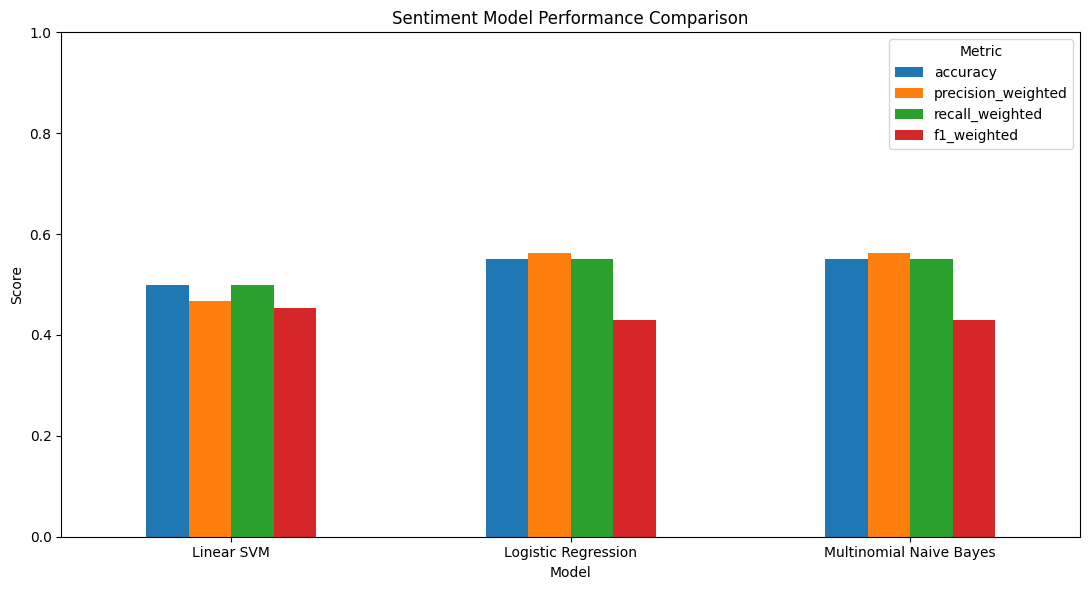

In [19]:
# ============================================================
# MODEL COMPARISON PLOT
# ============================================================

metrics = [
    "accuracy",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted"
]

plot_df = results_df.set_index("model")[metrics]

plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Sentiment Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 20. Select the Best Model

Select the classifier with the highest weighted F1-score.

The selected model will be used for the final prediction stage.

In [20]:
# ============================================================
# BEST MODEL SELECTION
# ============================================================

best_model_name = results_df.loc[0, "model"]

model_registry = {
    "Logistic Regression": logistic_model,
    "Multinomial Naive Bayes": nb_model,
    "Linear SVM": svm_model
}

best_model = model_registry[best_model_name]

print(f"Selected Best Model: {best_model_name}")

Selected Best Model: Linear SVM


## 21. Generate Final Sentiment Predictions

Apply the selected model to the complete NLP-ready dataset.

In [21]:
# ============================================================
# FINAL PREDICTIONS
# ============================================================

all_text_tfidf = tfidf.transform(
    df["processed_text"]
)

df["predicted_sentiment"] = best_model.predict(
    all_text_tfidf
)

display(
    df[
        [
            "original_text",
            "processed_text",
            "predicted_sentiment"
        ]
    ].head(10)
)

,original_text,processed_text,predicted_sentiment
0,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,world created process thinking changed without changing thinking,Positive
1,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",choice harry show truly far ability,Negative
2,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,two way live life one though nothing miracle though everything miracle,Negative
3,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",person gentleman lady pleasure good novel must intolerably stupid,Positive
4,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",imperfection beauty madness genius better absolutely ridiculous absolutely boring,Negative
5,“Try not to become a man of success. Rather become a man of value.”,try become man success rather become man value,Positive
6,“It is better to be hated for what you are than to be loved for what you are not.”,better hated loved,Positive
7,"“I have not failed. I've just found 10,000 ways that won't work.”",failed ive found way wont work,Negative
8,“A woman is like a tea bag; you never know how strong it is until it's in hot water.”,woman like tea bag never know strong hot water,Negative
9,"“A day without sunshine is like, you know, night.”",day without sunshine like know night,Negative


## 22. Generate Prediction Score

Generate a model score for each prediction.

For probabilistic models, the maximum class probability is used.

For Linear SVM, the maximum decision-function value is retained as a **confidence-like score**, not a calibrated probability.

In [22]:
# ============================================================
# PREDICTION SCORE
# ============================================================

if hasattr(best_model, "predict_proba"):
    probabilities = best_model.predict_proba(all_text_tfidf)
    df["prediction_score"] = probabilities.max(axis=1)
else:
    decision_values = best_model.decision_function(all_text_tfidf)

    if decision_values.ndim == 1:
        df["prediction_score"] = np.abs(decision_values)
    else:
        df["prediction_score"] = decision_values.max(axis=1)

print("Prediction score generated.")

display(
    df[
        [
            "processed_text",
            "predicted_sentiment",
            "prediction_score"
        ]
    ].head(10)
)

Prediction score generated.


,processed_text,predicted_sentiment,prediction_score
0,world created process thinking changed without changing thinking,Positive,0.625670
1,choice harry show truly far ability,Negative,-0.155010
2,two way live life one though nothing miracle though everything miracle,Negative,0.545688
3,person gentleman lady pleasure good novel must intolerably stupid,Positive,0.625305
4,imperfection beauty madness genius better absolutely ridiculous absolutely boring,Negative,0.578668
5,try become man success rather become man value,Positive,0.662241
6,better hated loved,Positive,0.642565
7,failed ive found way wont work,Negative,0.566597
8,woman like tea bag never know strong hot water,Negative,0.556795
9,day without sunshine like know night,Negative,0.585392


## 23. Confusion Matrix

Evaluate the selected model against the held-out weak labels.

The confusion matrix shows which classes are correctly or incorrectly predicted.

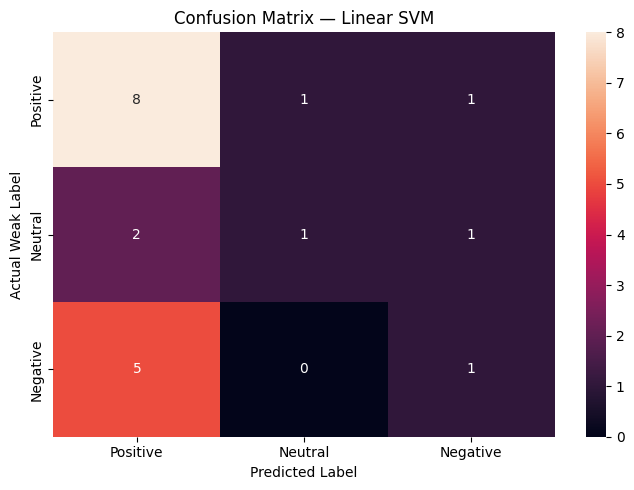

In [23]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

best_test_predictions = models_predictions[best_model_name]

labels = ["Positive", "Neutral", "Negative"]

cm = confusion_matrix(
    y_test,
    best_test_predictions,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Weak Label")
plt.tight_layout()
plt.show()

## 24. Error Analysis

Inspect examples where the selected model disagrees with the VADER weak label.

Because the reference labels are automatically generated, these should be interpreted as **model-vs-weak-label disagreements**, not necessarily true model errors.

In [24]:
# ============================================================
# ERROR ANALYSIS
# ============================================================

test_results = pd.DataFrame({
    "text": X_test.values,
    "actual_weak_label": y_test.values,
    "predicted_label": best_test_predictions
})

errors = test_results[
    test_results["actual_weak_label"]
    != test_results["predicted_label"]
].copy()

print(f"Test disagreements: {len(errors):,}")

display(errors.head(15))

Test disagreements: 10


,text,actual_weak_label,predicted_label
3,choice harry show truly far ability,Positive,Negative
4,opposite love hate indifference opposite art ugliness indifference opposite faith heresy indifference opposite life death indifference,Negative,Positive
5,never let schooling interfere education,Neutral,Negative
6,wander lost,Negative,Positive
8,one thing every day scare,Negative,Positive
9,truth everyone going hurt got find one worth suffering,Negative,Positive
10,never really understand person consider thing point view climb inside skin walk around,Neutral,Positive
14,every minute angry lose sixty second happiness,Negative,Positive
17,flower every time thought youi could walk garden forever,Neutral,Positive
19,want child intelligent read fairy tale want intelligent read fairy tale,Positive,Neutral


## 25. Prepare Final Sentiment Dataset

Create a clean analytical dataset containing the original text, processed text, sentiment scores, weak labels, model predictions, and source metadata.

In [25]:
# ============================================================
# FINAL SENTIMENT DATASET
# ============================================================

candidate_columns = [
    "quote_id",
    "original_text",
    "processed_text",
    "author",
    "tags",
    "source_url",
    "compound_score",
    "sentiment",
    "predicted_sentiment",
    "prediction_score"
]

final_columns = [
    column
    for column in candidate_columns
    if column in df.columns
]

sentiment_df = df[final_columns].copy()

display(sentiment_df.head(10))

,quote_id,original_text,processed_text,author,tags,source_url,compound_score,sentiment,predicted_sentiment,prediction_score
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,world created process thinking changed without changing thinking,Albert Einstein,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/,0.2500,Positive,Positive,0.625670
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",choice harry show truly far ability,J.K. Rowling,"abilities, choices",https://quotes.toscrape.com/,0.6369,Positive,Negative,-0.155010
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,two way live life one though nothing miracle though everything miracle,Albert Einstein,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/,-0.7306,Negative,Negative,0.545688
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",person gentleman lady pleasure good novel must intolerably stupid,Jane Austen,"aliteracy, books, classic, humor",https://quotes.toscrape.com/,0.6705,Positive,Positive,0.625305
4,5,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",imperfection beauty madness genius better absolutely ridiculous absolutely boring,Marilyn Monroe,"be-yourself, inspirational",https://quotes.toscrape.com/,-0.2143,Negative,Negative,0.578668
5,6,“Try not to become a man of success. Rather become a man of value.”,try become man success rather become man value,Albert Einstein,"adulthood, success, value",https://quotes.toscrape.com/,0.7269,Positive,Positive,0.662241
6,7,“It is better to be hated for what you are than to be loved for what you are not.”,better hated loved,André Gide,"life, love",https://quotes.toscrape.com/,0.3818,Positive,Positive,0.642565
7,8,"“I have not failed. I've just found 10,000 ways that won't work.”",failed ive found way wont work,Thomas A. Edison,"edison, failure, inspirational, paraphrased",https://quotes.toscrape.com/,-0.5106,Negative,Negative,0.566597
8,9,“A woman is like a tea bag; you never know how strong it is until it's in hot water.”,woman like tea bag never know strong hot water,Eleanor Roosevelt,misattributed-eleanor-roosevelt,https://quotes.toscrape.com/,-0.0521,Negative,Negative,0.556795
9,10,"“A day without sunshine is like, you know, night.”",day without sunshine like know night,Steve Martin,"humor, obvious, simile",https://quotes.toscrape.com/,-0.5773,Negative,Negative,0.585392


## 26. Sentiment Result Summary

Compare the VADER weak-label distribution with the machine-learning prediction distribution.

In [26]:
# ============================================================
# SENTIMENT RESULT SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Weak_Label_Count": df["sentiment"].value_counts(),
    "Model_Prediction_Count": df["predicted_sentiment"].value_counts()
}).fillna(0).astype(int)

display(summary)

,Weak_Label_Count,Model_Prediction_Count
Positive,47,52
Negative,32,29
Neutral,21,19


## 27. Save Final Sentiment Dataset

Save the final sentiment-analysis results to `data/final/`.

This dataset will be consumed by the next analysis stage.

In [27]:
# ============================================================
# SAVE SENTIMENT DATASET
# ============================================================

sentiment_df.to_csv(
    SENTIMENT_OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("Sentiment dataset saved successfully.")
print(f"Output: {SENTIMENT_OUTPUT_FILE}")

Sentiment dataset saved successfully.
Output: D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\final\sentiment_analysis_results.csv


## 28. Save Model Artifacts

Persist the selected classifier and fitted TF-IDF vectorizer.

Saving both artifacts allows the same text-processing and prediction pipeline to be reused later.

In [28]:
# ============================================================
# SAVE MODEL ARTIFACTS
# ============================================================

joblib.dump(
    best_model,
    BEST_MODEL_FILE
)

joblib.dump(
    tfidf,
    TFIDF_FILE
)

print("Model artifacts saved successfully.")
print(f"Model     : {BEST_MODEL_FILE}")
print(f"Vectorizer: {TFIDF_FILE}")

Model artifacts saved successfully.
Model     : D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\models\best_sentiment_model.pkl
Vectorizer: D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\models\tfidf_vectorizer.pkl


## 29. Verify Saved Outputs

Reload the final dataset and verify that the model artifacts exist.

In [29]:
# ============================================================
# VERIFY OUTPUTS
# ============================================================

saved_sentiment_df = pd.read_csv(
    SENTIMENT_OUTPUT_FILE
)

print(f"Final Dataset Shape: {saved_sentiment_df.shape}")
print(f"Model Exists       : {BEST_MODEL_FILE.exists()}")
print(f"Vectorizer Exists  : {TFIDF_FILE.exists()}")

display(saved_sentiment_df.head())

Final Dataset Shape: (100, 10)
Model Exists       : True
Vectorizer Exists  : True


,quote_id,original_text,processed_text,author,tags,source_url,compound_score,sentiment,predicted_sentiment,prediction_score
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,world created process thinking changed without changing thinking,Albert Einstein,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/,0.2500,Positive,Positive,0.625670
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",choice harry show truly far ability,J.K. Rowling,"abilities, choices",https://quotes.toscrape.com/,0.6369,Positive,Negative,-0.155010
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,two way live life one though nothing miracle though everything miracle,Albert Einstein,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/,-0.7306,Negative,Negative,0.545688
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",person gentleman lady pleasure good novel must intolerably stupid,Jane Austen,"aliteracy, books, classic, humor",https://quotes.toscrape.com/,0.6705,Positive,Positive,0.625305
4,5,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",imperfection beauty madness genius better absolutely ridiculous absolutely boring,Marilyn Monroe,"be-yourself, inspirational",https://quotes.toscrape.com/,-0.2143,Negative,Negative,0.578668


## 📊 Final Summary

The sentiment-analysis stage has completed the baseline NLP/ML classification workflow.

### Completed Tasks

- Loaded NLP-ready text
- Generated weak sentiment labels using VADER
- Created Positive, Neutral, and Negative classes
- Split data into training and testing sets
- Created TF-IDF features
- Trained Logistic Regression
- Trained Multinomial Naive Bayes
- Trained Linear SVM
- Compared model performance
- Evaluated Accuracy, Precision, Recall, and F1-score
- Generated classification reports
- Created a confusion matrix
- Performed basic error analysis
- Selected the best baseline model
- Generated sentiment predictions
- Generated prediction scores
- Saved the final sentiment dataset
- Saved the trained model and TF-IDF vectorizer

### Output Files

```text
data/final/sentiment_analysis_results.csv

models/best_sentiment_model.pkl

models/tfidf_vectorizer.pkl
```

### ⚠️ Evaluation Note

The current metrics measure agreement with **VADER-generated weak labels**, not performance against human-annotated ground truth.

For a production-ready project, the next iteration should use a properly labeled sentiment dataset and an evaluation protocol based on independent human-validated labels.

## 🔗 Notebook Navigation

**Previous:** `03_NLP_Preprocessing.ipynb`

**Current:** `04_Sentiment_Analysis.ipynb`

**Next:** `05_Keyword_and_Topic_Analysis.ipynb`

---

### 🚀 Next Stage

The next notebook will move beyond sentiment classification and extract deeper language intelligence through **keyword extraction, word/phrase analysis, and topic modeling**.